In [21]:
import sys
sys.path.insert(0, "..")
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.metrics import compute_metrics

LOG_PATH = Path("../log/")

log_files = sorted(LOG_PATH.glob("*.h5"))
for i, f in enumerate(log_files):
    print(f"{i}: {f.name}")

0: 20260422_003949.h5
1: 20260422_005759.h5
2: 20260422_005804.h5
3: 20260422_005809.h5
4: 20260422_005815.h5
5: 20260422_005820.h5
6: 20260422_005825.h5
7: 20260422_005831.h5
8: 20260422_005836.h5
9: 20260422_005841.h5
10: 20260422_005847.h5
11: 20260422_010010.h5
12: 20260422_010015.h5
13: 20260422_010020.h5
14: 20260422_010026.h5
15: 20260422_010031.h5
16: 20260422_010036.h5
17: 20260422_010042.h5
18: 20260422_010044.h5
19: 20260422_092122.h5
20: 20260422_092132.h5
21: 20260422_092143.h5
22: 20260422_092158.h5
23: 20260422_092300.h5
24: 20260422_092312.h5
25: 20260422_092323.h5
26: 20260422_094823.h5


In [22]:
# pick file by index or set path directly
path = log_files[-1]

with h5py.File(path, "r") as f:
    t   = f["t"][:]
    q1  = f["q1"][:]
    q2  = f["q2"][:]
    dq1 = f["dq1"][:]
    dq2 = f["dq2"][:]
    u   = f["u"][:]

q1 = np.arctan2(np.sin(q1), np.cos(q1))
q2 = np.arctan2(np.sin(q2), np.cos(q2))

metrics = compute_metrics(str(path), upright=np.array([np.pi/2, 0.0, 0.0, 0.0]))

print(f"RMS state error:      {metrics['rms_error']:.4f} rad")
print(f"RMS torque:           {metrics['rms_torque']:.4f} Nm")
print(f"Settling time:        {metrics['settling_time_s']:.3f} s")
print(f"Mean solve time:      {metrics['mean_solve_time_ms']:.3f} ms")
print(f"Max solve time:       {metrics['max_solve_time_ms']:.3f} ms")

print(f"Loaded: {path.name}  |  {len(t)} steps  |  duration {t[-1]:.2f}s")

RMS state error:      19.6638 rad
RMS torque:           3.6842 Nm
Settling time:        nan s
Mean solve time:      98.473 ms
Max solve time:       943.189 ms
Loaded: 20260422_094823.h5  |  2501 steps  |  duration 5.00s


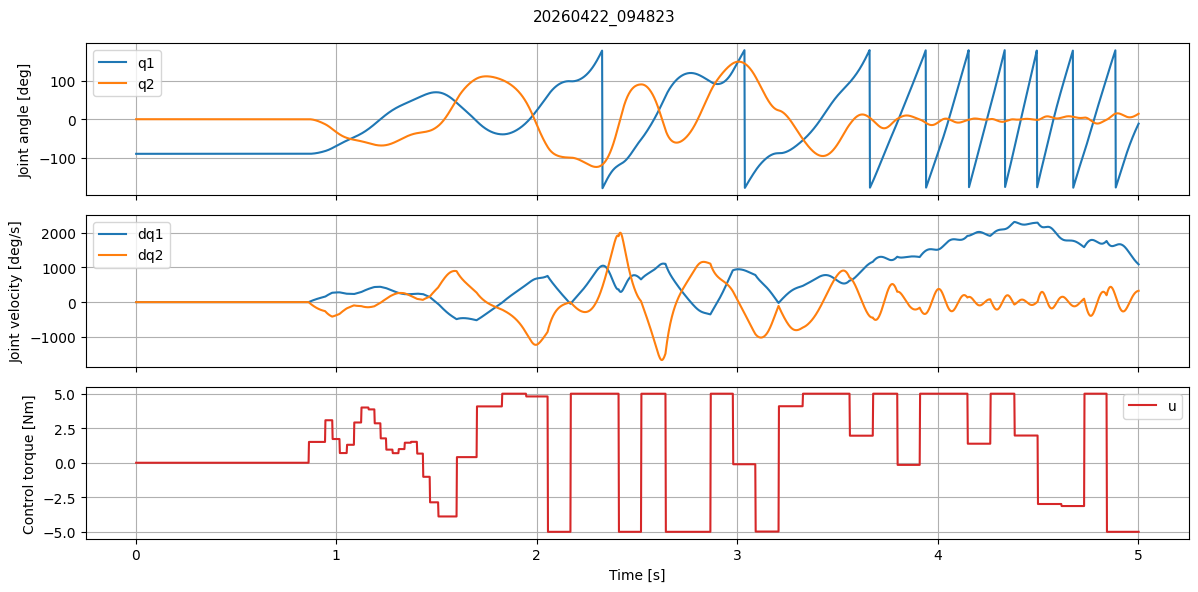

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
fig.suptitle(path.stem, fontsize=11)

axes[0].plot(t, np.degrees(q1), label="q1")
axes[0].plot(t, np.degrees(q2), label="q2")
axes[0].set_ylabel("Joint angle [deg]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, np.degrees(dq1), label="dq1")
axes[1].plot(t, np.degrees(dq2), label="dq2")
axes[1].set_ylabel("Joint velocity [deg/s]")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t, u, color="tab:red", label="u")
axes[2].set_ylabel("Control torque [Nm]")
axes[2].set_xlabel("Time [s]")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [24]:
target_state = [1.5708, 0.0, 0.0, 0.0]

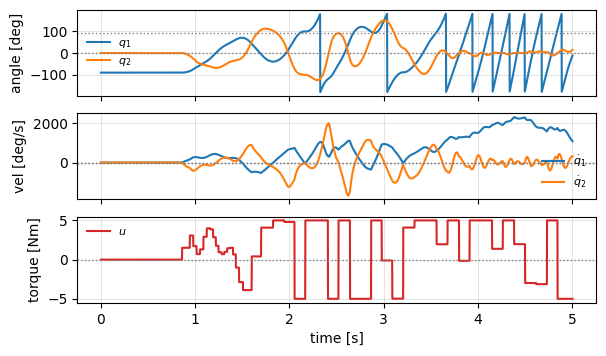

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

q1_ref, q2_ref, dq1_ref, dq2_ref = target_state

fig, axes = plt.subplots(3, 1, figsize=(6.0, 3.5), sharex=True)

# --- angles ---
axes[0].plot(t, np.degrees(q1), label=r"$q_1$", linewidth=1.5)
axes[0].plot(t, np.degrees(q2), label=r"$q_2$", linewidth=1.5)

axes[0].axhline(np.degrees(q1_ref), linestyle=":", color="gray", linewidth=1.0)
axes[0].axhline(np.degrees(q2_ref), linestyle=":", color="gray", linewidth=1.0)

axes[0].set_ylabel("angle [deg]")
axes[0].legend(loc="lower right", frameon=False)  # <-- key change
axes[0].legend(fontsize=8, frameon=False)
axes[0].grid(True, linewidth=0.5, alpha=0.5)

# --- velocities ---
axes[1].plot(t, np.degrees(dq1), label=r"$\dot{q}_1$", linewidth=1.5)
axes[1].plot(t, np.degrees(dq2), label=r"$\dot{q}_2$", linewidth=1.5)

axes[1].axhline(np.degrees(dq1_ref), linestyle=":", color="gray", linewidth=1.0)
axes[1].axhline(np.degrees(dq2_ref), linestyle=":", color="gray", linewidth=1.0)

axes[1].set_ylabel("vel [deg/s]")
axes[1].legend(loc="upper right", frameon=False)
axes[1].legend(fontsize=8, frameon=False)
axes[1].grid(True, linewidth=0.5, alpha=0.5)

# --- torque ---
axes[2].plot(t, u, color="tab:red", label=r"$u$", linewidth=1.5)
axes[2].axhline(0.0, linestyle=":", color="gray", linewidth=1.0)

axes[2].set_ylabel("torque [Nm]")
axes[2].set_xlabel("time [s]")
axes[2].legend(loc="upper right", frameon=False)
axes[2].legend(fontsize=8, frameon=False)
axes[2].grid(True, linewidth=0.5, alpha=0.5)

plt.tight_layout(pad=0.5)

plt.savefig("mpc_nominal_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()